<a href="https://colab.research.google.com/github/stiltnerag/INFO648/blob/main/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

#Part A - Winsorization (Outlier Handling)

In [3]:
df=pd.read_csv("/content/cps_with_education-1 (1).csv")

In [5]:
#df.head()
#df.describe()
df['YEAR'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

In [9]:
df_clean= df[(df['EARNWEEK2']<99999) &(df['EARNWEEK2']>100)&(df['YEAR']>2023)].copy()

In [10]:
df_clean['YEAR'].unique()

array([2024, 2025])

In [12]:
#df.describe()
df_clean['SEX'].value_counts()

,count
SEX,
1,121202
2,115532


In [18]:
Male=df_clean[df_clean['SEX']==1].copy()
female=df_clean[df_clean['SEX']==2].copy()

In [15]:
import matplotlib.pyplot as plt

In [27]:
b_cut=Male['EARNWEEK2'].quantile(.95)
m_cut=female['EARNWEEK2'].quantile(.95)
print(m_cut,b_cut)

2884.61 3840.0


In [29]:
Male['EARNWEEK2_w95']=Male['EARNWEEK2']
Male.loc[Male['EARNWEEK2']>b_cut,"EARNWEEK2_w95"]=b_cut

female['EARNWEEK2_w95']=female['EARNWEEK2']
female.loc[female['EARNWEEK2']>m_cut,"EARNWEEK2_w95"]=m_cut
female.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,EARNWEEK2_w95
3076330,3076330,2024,40,700.0,23,2,1,Some College,700.0
3076332,3076332,2024,35,516.0,64,2,1,Some College,516.0
3076333,3076333,2024,40,720.0,57,2,1,Some College,720.0
3076343,3076343,2024,997,2780.0,54,2,1,Bachelor's,2780.0
3076345,3076345,2024,40,654.0,60,2,1,Associate's,654.0


In [31]:
Male.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,EARNWEEK2_w95
3076326,3076326,2024,40,520.0,36,1,1,Some College,520.0
3076334,3076334,2024,12,220.0,69,1,1,Some College,220.0
3076344,3076344,2024,40,2880.0,64,1,1,Graduate / Professional,2880.0
3076347,3076347,2024,60,1730.0,58,1,1,Some College,1730.0
3076349,3076349,2024,40,880.0,47,1,1,Bachelor's,880.0


In [35]:
df_winsorized_earnings = winsorize_by_group(df_combined, ['SEX', 'YEAR'], 'EARNWEEK2', percentile=95)
# table for cut off score for all four groups

95th percentile cutoff for Men-2024: 3680.00
95th percentile cutoff for Men-2025: 3900.00
95th percentile cutoff for Women-2024: 2880.00
95th percentile cutoff for Women-2025: 2980.00


In [36]:
print("Winsorized Sample Sizes:")
sample_sizes = df_winsorized_earnings.groupby(['SEX', 'YEAR']).size()

# Rename sex values for better readability
sex_mapping = {1: 'Men', 2: 'Women'}

for (sex_val, year_val), size in sample_sizes.items():
    group_name = f"{sex_mapping[sex_val]}-{year_val}"
    print(f"  {group_name}: {size}")
#short table with sample size for all four groups:

Winsorized Sample Sizes:
  Men-2024: 65830
  Men-2025: 55372
  Women-2024: 62815
  Women-2025: 52717


#Part B - Confidence Intervals for Population Mean Earnings

In [37]:
import numpy as np
from scipy import stats

def calculate_confidence_interval(df_group, column='EARNWEEK2_winsorized', z_score=1.96):
    """Calculates the 95% confidence interval for the mean of a given column."""
    if df_group.empty:
        return (np.nan, np.nan)

    x_bar = df_group[column].mean()  # Sample mean
    s = df_group[column].std()       # Sample standard deviation
    n = len(df_group)                # Sample size

    if n == 0:
        return (np.nan, np.nan)

    # Calculate the margin of error
    margin_of_error = z_score * (s / np.sqrt(n))

    # Calculate the confidence interval
    lower_bound = x_bar - margin_of_error
    upper_bound = x_bar + margin_of_error

    return (lower_bound, upper_bound)

# Define the four groups. Assume df_winsorized_earnings is already available.
groups_data = {
    'Men-2024': df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 1) & (df_winsorized_earnings['YEAR'] == 2024)],
    'Men-2025': df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 1) & (df_winsorized_earnings['YEAR'] == 2025)],
    'Women-2024': df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 2) & (df_winsorized_earnings['YEAR'] == 2024)],
    'Women-2025': df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 2) & (df_winsorized_earnings['YEAR'] == 2025)]
}

print("95% Confidence Intervals for Winsorized Weekly Earnings:")
for group_name, df_group in groups_data.items():
    lower, upper = calculate_confidence_interval(df_group, column='EARNWEEK2_winsorized')
    print(f"  {group_name}: ({lower:.2f}, {upper:.2f})")

95% Confidence Intervals for Winsorized Weekly Earnings:
  Men-2024: (1421.40, 1435.32)
  Men-2025: (1491.98, 1508.27)
  Women-2024: (1105.79, 1116.97)
  Women-2025: (1142.53, 1155.19)


The 95% confidence internaval for population mean weekly earnings is stating that we are 95% confident that the mean weekly earnings for population of males and females in 2024 & 2025 fall within these intervals. We see with the data set that for 2024 (1421.40, 1435.32) & 2025 (1491.98, 1508.27) for the men the CIs do not overlap for either year, indiciating that the mean weekly earnings for men were higher in 2025 than 2024. The same we see for the women no overlap year over year, this gives confidence that these are unlikely chance rather true increase in earnings.  

#Part C - Hypothesis Tests: Did the Population Mean Change?

Ho: The mean for Male 2024 $$H_o: \mu_{2024} =\mu_{2025}$$
Ha: The mean for Male 2024 $$H_a: \mu_{2024} \neq \mu_{2025}$$


Ho: The mean for Female 2024 $$H_o: \mu_{2024} =\mu_{2025}$$
Ha: The mean for Female 2024 $$H_a: \mu_{2024} \neq \mu_{2025}$$

In [56]:
m_2024 = Male[Male["YEAR"] == 2024]["EARNWEEK2_w95"]
m_2025 = Male[Male["YEAR"] == 2025]["EARNWEEK2_w95"]

w_2024 = female[female["YEAR"] == 2024]["EARNWEEK2_w95"]
w_2025 = female[female["YEAR"] == 2025]["EARNWEEK2_w95"]

In [57]:
# Compute Welch's t-test (equal_var=False handles different variances safely)
t_stat_m, p_val_m = stats.ttest_ind(m_2025, m_2024, equal_var=False)
t_stat_w, p_val_w = stats.ttest_ind(w_2025, w_2024, equal_var=False)

In [58]:
print(f"--- MEN STATS ---")
print(f"2024 Mean: {m_2024.mean():.4f} | 2025 Mean: {m_2025.mean():.4f}")
print(f"Difference (2025 - 2024): {m_2025.mean() - m_2024.mean():.4f}")
print(f"P-value: {p_val_m}")

print(f"\n--- WOMEN STATS ---")
print(f"2024 Mean: {w_2024.mean():.4f} | 2025 Mean: {w_2025.mean():.4f}")
print(f"Difference (2025 - 2024): {w_2025.mean() - w_2024.mean():.4f}")
print(f"P-value: {p_val_w}")

--- MEN STATS ---
2024 Mean: 1436.1316 | 2025 Mean: 1497.1021
Difference (2025 - 2024): 60.9705
P-value: 1.338215988761604e-28

--- WOMEN STATS ---
2024 Mean: 1111.6037 | 2025 Mean: 1143.9244
Difference (2025 - 2024): 32.3207
P-value: 3.9196704866437556e-14


#Male Results:
2024 Winsorized Sample Mean ($\bar{x}_{2024}$): 1436.1316
2025 Winsorized Sample Mean ($\bar{x}_{2025}$): 1497.1021
Difference ($\bar{x}_{2025} - \bar{x}_{2024}$): 60.9705
$p$-value: 0.0000

#Female Results
2024 Winsorized Sample Mean ($\bar{x}_{2024}$): 111.6037
2025 Winsorized Sample Mean ($\bar{x}_{2025}$): 1143.9244
Difference ($\bar{x}_{2025} - \bar{x}_{2024}$): 32.3207
$p$-value: 0.0000


Given the scientific notation for each data set we reject the null hypothesis for both men and women. This concludes that population average weekly earnings for both men and women in 2024 & 2025 are not equal.

#Part D - Statistical vs. Practical Significance

In [60]:
male_mean_2024 = m_2024.mean()
male_mean_2025 = m_2025.mean()

female_mean_2024 = w_2024.mean()
female_mean_2025 = w_2025.mean()

percent_change_male = ((male_mean_2025 - male_mean_2024) / male_mean_2024) * 100
percent_change_female = ((female_mean_2025 - female_mean_2024) / female_mean_2024) * 100

print(f"Percentage Change in Winsorized Mean Weekly Earnings for Men (2024 to 2025): {percent_change_male:.2f}%")
print(f"Percentage Change in Winsorized Mean Weekly Earnings for Women (2024 to 2025): {percent_change_female:.2f}%")

Percentage Change in Winsorized Mean Weekly Earnings for Men (2024 to 2025): 4.25%
Percentage Change in Winsorized Mean Weekly Earnings for Women (2024 to 2025): 2.91%


### Cohen's d for Men (2024 vs. 2025)

In [61]:
import numpy as np

# Means
mean_m_2024 = m_2024.mean()
mean_m_2025 = m_2025.mean()

# Standard deviations
std_m_2024 = m_2024.std()
std_m_2025 = m_2025.std()

# Sample sizes
n_m_2024 = len(m_2024)
n_m_2025 = len(m_2025)

# Pooled standard deviation (sp)
sp_m = np.sqrt(((n_m_2024 - 1) * std_m_2024**2 + (n_m_2025 - 1) * std_m_2025**2) / (n_m_2024 + n_m_2025 - 2))

# Cohen's d
cohens_d_m = (mean_m_2025 - mean_m_2024) / sp_m

print(f"Pooled Standard Deviation for Men: {sp_m:.2f}")
print(f"Cohen's d for Men: {cohens_d_m:.4f}")

Pooled Standard Deviation for Men: 949.34
Cohen's d for Men: 0.0642


### Cohen's d for Women (2024 vs. 2025)

In [62]:
# Means
mean_w_2024 = w_2024.mean()
mean_w_2025 = w_2025.mean()

# Standard deviations
std_w_2024 = w_2024.std()
std_w_2025 = w_2025.std()

# Sample sizes
n_w_2024 = len(w_2024)
n_w_2025 = len(w_2025)

# Pooled standard deviation (sp)
sp_w = np.sqrt(((n_w_2024 - 1) * std_w_2024**2 + (n_w_2025 - 1) * std_w_2025**2) / (n_w_2024 + n_w_2025 - 2))

# Cohen's d
cohens_d_w = (mean_w_2025 - mean_w_2024) / sp_w

print(f"Pooled Standard Deviation for Women: {sp_w:.2f}")
print(f"Cohen's d for Women: {cohens_d_w:.4f}")

Pooled Standard Deviation for Women: 722.07
Cohen's d for Women: 0.0448


Cohen's *d* for men is 0.0642 which is small and for women it is 0.0448 which is also small. The p-values are so small due to the massive sample size causing a drastic reduction in standard error so this makes t-test very senstitive. Statistical significance confirms that the earnings change is not a random sampling fluke. Practical significance determines if the very small shift in relation to the std is large enough to be meaningful within the economic context.

#Part E - CPI Check: Are Earnings "Keeping Up"?

Using a CPI for good of 2.7% compared to the male salary increase of 4.25% the males are seeing earnings quite a bit over the CPI, however the females do not see such a large jump as theirs 2024-2025 only increased 2.91%. This does infer that both groups are exceeding the 2.7% but men are growing nearly half as fast as women's over the same period of time. The caution is that this is reflective of an overall sample and does not mean this is what each individual is experiencing within the sample.

#Part F - Plots

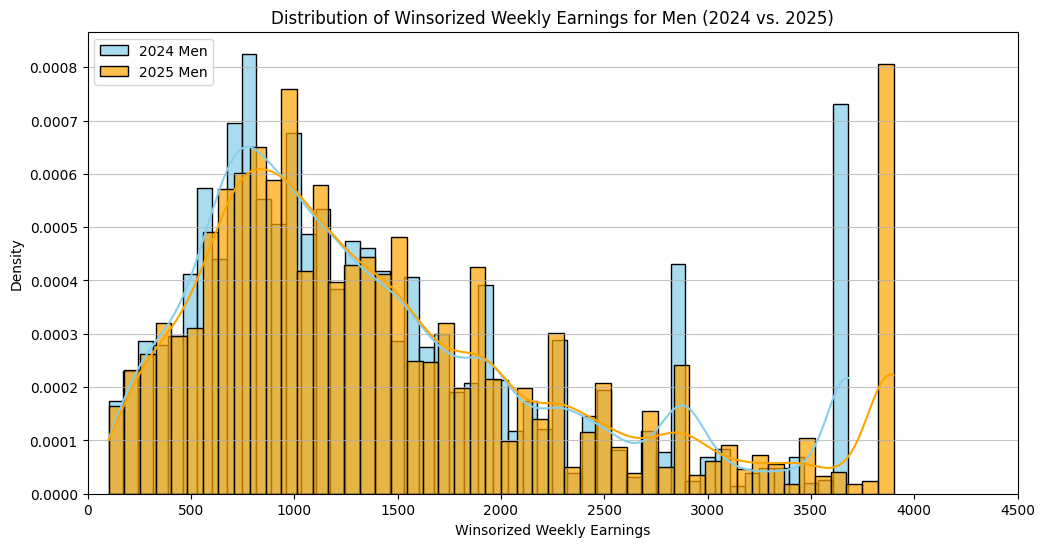

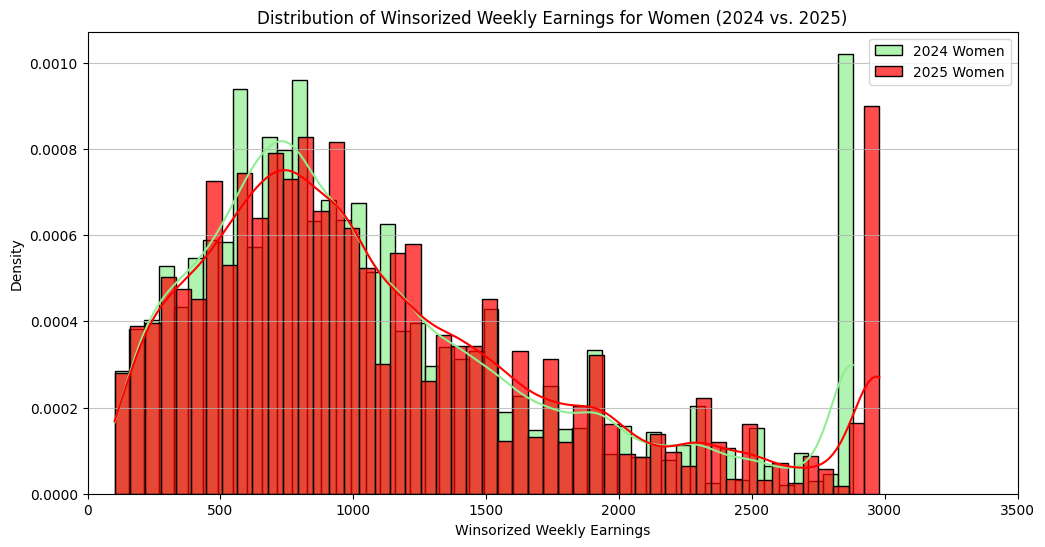

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for men and women for 2024 and 2025
men_2024_winsorized = df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 1) & (df_winsorized_earnings['YEAR'] == 2024)]['EARNWEEK2_winsorized']
men_2025_winsorized = df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 1) & (df_winsorized_earnings['YEAR'] == 2025)]['EARNWEEK2_winsorized']

women_2024_winsorized = df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 2) & (df_winsorized_earnings['YEAR'] == 2024)]['EARNWEEK2_winsorized']
women_2025_winsorized = df_winsorized_earnings[(df_winsorized_earnings['SEX'] == 2) & (df_winsorized_earnings['YEAR'] == 2025)]['EARNWEEK2_winsorized']

# Plot for Men
plt.figure(figsize=(12, 6))
sns.histplot(men_2024_winsorized, color='skyblue', label='2024 Men', kde=True, stat='density', alpha=0.7, bins=50)
sns.histplot(men_2025_winsorized, color='orange', label='2025 Men', kde=True, stat='density', alpha=0.7, bins=50)
plt.title('Distribution of Winsorized Weekly Earnings for Men (2024 vs. 2025)')
plt.xlabel('Winsorized Weekly Earnings')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, 4500) # Set a reasonable x-limit based on winsorization cutoffs
plt.show()

# Plot for Women
plt.figure(figsize=(12, 6))
sns.histplot(women_2024_winsorized, color='lightgreen', label='2024 Women', kde=True, stat='density', alpha=0.7, bins=50)
sns.histplot(women_2025_winsorized, color='red', label='2025 Women', kde=True, stat='density', alpha=0.7, bins=50)
plt.title('Distribution of Winsorized Weekly Earnings for Women (2024 vs. 2025)')
plt.xlabel('Winsorized Weekly Earnings')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, 3500) # Set a reasonable x-limit based on winsorization cutoffs
plt.show()

### Mean Winsorized Weekly Earnings with 95% Confidence Intervals

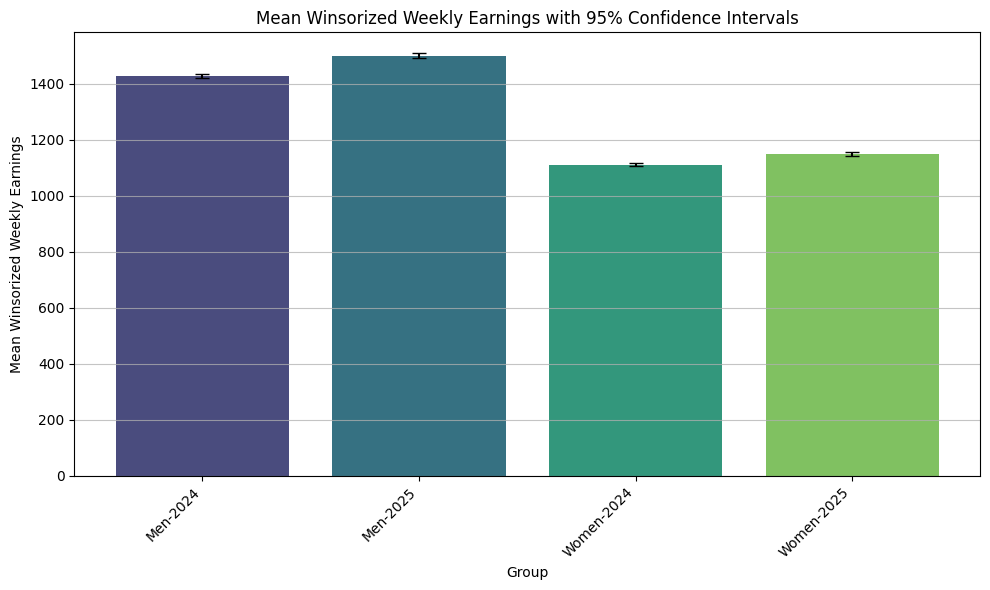

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-extract means and confidence intervals, or use stored values if available
plot_data = []
for group_name, df_group in groups_data.items():
    mean_val = df_group['EARNWEEK2_winsorized'].mean()
    lower, upper = calculate_confidence_interval(df_group, column='EARNWEEK2_winsorized')
    plot_data.append({'Group': group_name, 'Mean': mean_val, 'Lower_CI': lower, 'Upper_CI': upper})

plot_df = pd.DataFrame(plot_data)

# Calculate error bar values (distance from mean)
plot_df['Error'] = plot_df['Mean'] - plot_df['Lower_CI']

plt.figure(figsize=(10, 6))
sns.barplot(x='Group', y='Mean', data=plot_df, palette='viridis', hue='Group', legend=False) # Plot bars for means

# Add error bars manually
plt.errorbar(x=plot_df['Group'], y=plot_df['Mean'], yerr=plot_df['Error'], fmt='none', c='black', capsize=5)

plt.title('Mean Winsorized Weekly Earnings with 95% Confidence Intervals')
plt.xlabel('Group')
plt.ylabel('Mean Winsorized Weekly Earnings')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

When we look at the bar chart for mean winzorized weekly earnings we realize how small teh CI's are relative to the size of the bars, we knew the sample size was large but this really puts it into perspective. Both men and womens distribution charts are skewed right.